In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mahbubaeka/dhaka-hourly-pm2-5-airnow-openaq-8415/pm25_sensor_24434.csv
/kaggle/input/datasets/mahbubaeka/dhaka-hourly-weather-era5-via-open-meteo/weather_era5_dhaka.csv


In [17]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for f in filenames:
        print(os.path.join(dirname, f))

/kaggle/input/datasets/mahbubaeka/dhaka-hourly-pm2-5-airnow-openaq-8415/pm25_sensor_24434.csv
/kaggle/input/datasets/mahbubaeka/dhaka-hourly-weather-era5-via-open-meteo/weather_era5_dhaka.csv


In [18]:
import pandas as pd

PM25_PATH = "/kaggle/input/datasets/mahbubaeka/dhaka-hourly-pm2-5-airnow-openaq-8415/pm25_sensor_24434.csv"
WEATHER_PATH = "/kaggle/input/datasets/mahbubaeka/dhaka-hourly-weather-era5-via-open-meteo/weather_era5_dhaka.csv"

pm25 = pd.read_csv(PM25_PATH)
weather = pd.read_csv(WEATHER_PATH)

for name, df in [("pm25", pm25), ("weather", weather)]:
    print(name, df.shape)
    print(df.columns.tolist())
    print(df.dtypes)
    print(df.head(3))
    print()

pm25 (66379, 5)
['value', 'from_utc', 'to_utc', 'from_local', 'to_local']
value         float64
from_utc       object
to_utc         object
from_local     object
to_local       object
dtype: object
   value              from_utc                to_utc  \
0   61.7  2016-11-09T17:00:00Z  2016-11-09T18:00:00Z   
1   67.8  2016-11-09T18:00:00Z  2016-11-09T19:00:00Z   
2  109.9  2016-11-09T19:00:00Z  2016-11-09T20:00:00Z   

                  from_local                   to_local  
0  2016-11-09T23:00:00+06:00  2016-11-10T00:00:00+06:00  
1  2016-11-10T00:00:00+06:00  2016-11-10T01:00:00+06:00  
2  2016-11-10T01:00:00+06:00  2016-11-10T02:00:00+06:00  

weather (73416, 4)
['time_local', 'temperature_2m', 'rain', 'wind_speed_10m']
time_local         object
temperature_2m    float64
rain              float64
wind_speed_10m    float64
dtype: object
         time_local  temperature_2m  rain  wind_speed_10m
0  2016-11-09T00:00            21.6   0.0             5.1
1  2016-11-09T01:00            2

In [19]:
pm25["time"] = pd.to_datetime(pm25["from_local"].str[:19])
weather["time"] = pd.to_datetime(weather["time_local"])

pm25_end = pd.to_datetime(pm25["to_local"].str[:19])

for name, df in [("pm25", pm25), ("weather", weather)]:
    print(name)
    print("first:", df["time"].min(), "| last:", df["time"].max())
    print("unique:", df["time"].is_unique, "| sorted:", df["time"].is_monotonic_increasing)
    print()

print("PM2.5 row length (to_local - from_local):")
print((pm25_end - pm25["time"]).value_counts())

pm25
first: 2016-11-09 23:00:00 | last: 2025-03-24 18:00:00
unique: True | sorted: True

weather
first: 2016-11-09 00:00:00 | last: 2025-03-25 23:00:00
unique: True | sorted: True

PM2.5 row length (to_local - from_local):
0 days 01:00:00    66379
Name: count, dtype: int64


In [20]:
full_index = pd.date_range(pm25["time"].min(), pm25["time"].max(), freq="h")
hourly = pm25.set_index("time")["value"].reindex(full_index)
hourly.index.name = "time"

print("hourly slots:", len(hourly))
print("slots with a value:", hourly.notna().sum(), f"({hourly.notna().mean()*100:.1f}%)")
print("slots without a value:", hourly.isna().sum())
print()

valid_per_day = hourly.notna().groupby(hourly.index.date).sum()
print("days:", len(valid_per_day))
print(valid_per_day.describe())
print()
print(valid_per_day.value_counts().sort_index())

hourly slots: 73364
slots with a value: 61229 (83.5%)
slots without a value: 12135

days: 3058
count    3058.000000
mean       20.022564
std         7.274951
min         0.000000
25%        21.000000
50%        24.000000
75%        24.000000
max        24.000000
Name: value, dtype: float64

value
0      225
1       16
2        7
3       12
4        8
5       15
6       16
7       64
8        8
9        9
10      16
11      24
12      13
13      20
14      26
15      23
16      33
17      78
18      33
19      41
20      64
21      86
22     183
23     433
24    1605
Name: count, dtype: int64


In [21]:
MIN_HOURS = 18

daily_hours = hourly.notna().groupby(hourly.index.date).sum()
daily_mean = hourly.groupby(hourly.index.date).mean()

daily = pd.DataFrame({"pm25_mean": daily_mean, "valid_hours": daily_hours})
daily.index = pd.to_datetime(daily.index)
daily.index.name = "date"

daily = daily.loc["2016-11-10":"2025-03-23"]
daily.loc[daily["valid_hours"] < MIN_HOURS, "pm25_mean"] = float("nan")

valid = daily["pm25_mean"].notna()
print("days in range:", len(daily))
print("valid days (>= 18 hours):", valid.sum(), f"({valid.mean()*100:.1f}%)")
print("invalid days:", (~valid).sum())
print()

streak_id = (valid != valid.shift()).cumsum()
streaks = valid.groupby(streak_id).agg(["first", "size"])
valid_streaks = streaks[streaks["first"]]["size"]
print("number of valid streaks:", len(valid_streaks))
print("longest 5 streaks (days):", valid_streaks.sort_values(ascending=False).head(5).tolist())
print("(today valid, tomorrow valid) pairs:", (valid & valid.shift(-1, fill_value=False)).sum())

days in range: 3056
valid days (>= 18 hours): 2444 (80.0%)
invalid days: 612

number of valid streaks: 178
longest 5 streaks (days): [243, 146, 73, 43, 38]
(today valid, tomorrow valid) pairs: 2266


In [22]:
w = weather.set_index("time")
daily_weather = pd.DataFrame({
    "temp_mean": w["temperature_2m"].groupby(w.index.date).mean(),
    "rain_sum": w["rain"].groupby(w.index.date).sum(),
    "wind_mean": w["wind_speed_10m"].groupby(w.index.date).mean(),
})
daily_weather.index = pd.to_datetime(daily_weather.index)
daily_weather.index.name = "date"

data = daily[["pm25_mean"]].join(daily_weather)
data = data.rename(columns={"pm25_mean": "pm25_today"})
data["pm25_yesterday"] = data["pm25_today"].shift(1)
data["pm25_2days_ago"] = data["pm25_today"].shift(2)
data["target_tomorrow"] = data["pm25_today"].shift(-1)

print("missing values per column:")
print(data.isna().sum())
print()

needs = {
    "today only (baseline)": ["pm25_today", "target_tomorrow"],
    "today + yesterday": ["pm25_today", "pm25_yesterday", "target_tomorrow"],
    "today + yesterday + 2 days ago": ["pm25_today", "pm25_yesterday", "pm25_2days_ago", "target_tomorrow"],
}
for label, cols in needs.items():
    print(f"{label}: {data.dropna(subset=cols).shape[0]} rows")

missing values per column:
pm25_today         612
temp_mean            0
rain_sum             0
wind_mean            0
pm25_yesterday     613
pm25_2days_ago     614
target_tomorrow    613
dtype: int64

today only (baseline): 2266 rows
today + yesterday: 2116 rows
today + yesterday + 2 days ago: 1985 rows


In [23]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

model_data = data.dropna(
    subset=["pm25_today", "pm25_yesterday", "pm25_2days_ago", "target_tomorrow"]
).copy()
print("rows for modelling:", len(model_data))

split = int(len(model_data) * 0.8)
train = model_data.iloc[:split]
test = model_data.iloc[split:]
print("train:", len(train), "rows,", train.index.min().date(), "to", train.index.max().date())
print("test: ", len(test), "rows,", test.index.min().date(), "to", test.index.max().date())
print()

def report(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name}: MAE = {mae:.1f}, RMSE = {rmse:.1f}")

y_test = test["target_tomorrow"]
report("persistence (tomorrow = today)", y_test, test["pm25_today"])
report("train average (same value every day)", y_test, np.full(len(test), train["target_tomorrow"].mean()))
print()
print("target in train:")
print(train["target_tomorrow"].describe())
print("target in test:")
print(test["target_tomorrow"].describe())

rows for modelling: 1985
train: 1588 rows, 2016-11-12 to 2024-01-20
test:  397 rows, 2024-01-21 to 2025-03-22

persistence (tomorrow = today): MAE = 25.5, RMSE = 36.9
train average (same value every day): MAE = 58.1, RMSE = 73.0

target in train:
count    1588.000000
mean       92.394824
std        65.706101
min         6.318182
25%        38.431159
50%        69.821970
75%       136.611413
max       344.791667
Name: target_tomorrow, dtype: float64
target in test:
count    397.000000
mean     108.541040
std       71.326935
min        9.458333
25%       48.583333
50%       86.458333
75%      162.208333
max      383.416667
Name: target_tomorrow, dtype: float64


In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

pm25_features = ["pm25_today", "pm25_yesterday", "pm25_2days_ago"]
weather_features = ["temp_mean", "rain_sum", "wind_mean"]
feature_sets = {
    "A: PM2.5 only": pm25_features,
    "B: PM2.5 + weather": pm25_features + weather_features,
}

results = []
fitted = {}

def add_result(name, features, y_pred):
    results.append({
        "model": name,
        "inputs": features,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    })

add_result("persistence", "pm25_today", test["pm25_today"])

for set_name, cols in feature_sets.items():
    lin = LinearRegression().fit(train[cols], train["target_tomorrow"])
    add_result("linear regression", set_name, lin.predict(test[cols]))
    fitted[("linear", set_name)] = lin

    rf = RandomForestRegressor(
        n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1
    ).fit(train[cols], train["target_tomorrow"])
    add_result("random forest", set_name, rf.predict(test[cols]))
    fitted[("forest", set_name)] = rf

results_table = pd.DataFrame(results).round(1)
print(results_table.to_string(index=False))

            model             inputs  MAE  RMSE
      persistence         pm25_today 25.5  36.9
linear regression      A: PM2.5 only 24.1  34.7
    random forest      A: PM2.5 only 24.6  34.9
linear regression B: PM2.5 + weather 22.2  32.4
    random forest B: PM2.5 + weather 22.3  32.0


In [25]:
from sklearn.model_selection import TimeSeriesSplit

all_features = pm25_features + weather_features
tscv = TimeSeriesSplit(n_splits=5)

rows = []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(model_data), start=1):
    tr = model_data.iloc[tr_idx]
    te = model_data.iloc[te_idx]
    y_tr = tr["target_tomorrow"]
    y_te = te["target_tomorrow"]

    lin_a = LinearRegression().fit(tr[pm25_features], y_tr)
    lin_b = LinearRegression().fit(tr[all_features], y_tr)
    rf_b = RandomForestRegressor(
        n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1
    ).fit(tr[all_features], y_tr)

    rows.append({
        "fold": fold,
        "train_rows": len(tr),
        "test_period": f"{te.index.min().date()} to {te.index.max().date()}",
        "persistence": mean_absolute_error(y_te, te["pm25_today"]),
        "linear A": mean_absolute_error(y_te, lin_a.predict(te[pm25_features])),
        "linear B": mean_absolute_error(y_te, lin_b.predict(te[all_features])),
        "forest B": mean_absolute_error(y_te, rf_b.predict(te[all_features])),
    })

cv = pd.DataFrame(rows)
print(cv.round(1).to_string(index=False))
print()
print("mean MAE across folds:")
print(cv[["persistence", "linear A", "linear B", "forest B"]].mean().round(1))

 fold  train_rows              test_period  persistence  linear A  linear B  forest B
    1         335 2019-01-09 to 2020-04-04         25.3      24.7      22.8      22.6
    2         665 2020-04-05 to 2021-10-17         18.4      18.6      18.6      17.8
    3         995 2021-10-18 to 2023-04-08         20.5      19.6      18.5      19.5
    4        1325 2023-04-09 to 2024-04-08         20.3      20.3      19.2      18.8
    5        1655 2024-04-09 to 2025-03-22         24.2      22.9      20.9      21.4

mean MAE across folds:
persistence    21.7
linear A       21.2
linear B       20.0
forest B       20.0
dtype: float64


In [26]:
from sklearn.inspection import permutation_importance

cols = all_features
X_test_b = test[cols]

for key, label in [
    (("linear", "B: PM2.5 + weather"), "linear regression B"),
    (("forest", "B: PM2.5 + weather"), "random forest B"),
]:
    model = fitted[key]
    r = permutation_importance(
        model, X_test_b, y_test,
        scoring="neg_mean_absolute_error", n_repeats=20, random_state=42,
    )
    imp = pd.DataFrame({
        "feature": cols,
        "MAE increase": r.importances_mean,
        "std": r.importances_std,
    }).sort_values("MAE increase", ascending=False)
    print(label)
    print(imp.round(2).to_string(index=False))
    print()

lin_b = fitted[("linear", "B: PM2.5 + weather")]
print("linear regression B coefficients:")
print(pd.Series(lin_b.coef_, index=cols).round(2))
print("intercept:", round(lin_b.intercept_, 1))

linear regression B
       feature  MAE increase  std
    pm25_today         26.36 1.26
     temp_mean          7.43 0.70
pm25_2days_ago          0.66 0.23
      rain_sum          0.30 0.12
pm25_yesterday          0.27 0.15
     wind_mean          0.02 0.04

random forest B
       feature  MAE increase  std
    pm25_today         29.51 1.20
     temp_mean          4.42 0.49
      rain_sum          0.99 0.29
pm25_yesterday          0.68 0.23
pm25_2days_ago          0.41 0.20
     wind_mean         -0.02 0.19

linear regression B coefficients:
pm25_today        0.55
pm25_yesterday    0.06
pm25_2days_ago    0.08
temp_mean        -3.59
rain_sum         -0.37
wind_mean        -0.34
dtype: float64
intercept: 126.1


In [27]:
doy = model_data.index.dayofyear
model_data["season_sin"] = np.sin(2 * np.pi * doy / 365.25)
model_data["season_cos"] = np.cos(2 * np.pi * doy / 365.25)
season_features = ["season_sin", "season_cos"]
features_c = all_features + season_features

rows = []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(model_data), start=1):
    tr = model_data.iloc[tr_idx]
    te = model_data.iloc[te_idx]
    y_tr = tr["target_tomorrow"]
    y_te = te["target_tomorrow"]

    lin_s = LinearRegression().fit(tr[pm25_features + season_features], y_tr)
    lin_b = LinearRegression().fit(tr[all_features], y_tr)
    lin_c = LinearRegression().fit(tr[features_c], y_tr)

    rows.append({
        "fold": fold,
        "persistence": mean_absolute_error(y_te, te["pm25_today"]),
        "PM2.5 + season": mean_absolute_error(y_te, lin_s.predict(te[pm25_features + season_features])),
        "B (weather)": mean_absolute_error(y_te, lin_b.predict(te[all_features])),
        "B + season": mean_absolute_error(y_te, lin_c.predict(te[features_c])),
    })

cv2 = pd.DataFrame(rows)
print(cv2.round(1).to_string(index=False))
print()
print("mean MAE across folds:")
print(cv2.drop(columns="fold").mean().round(1))
print()

train = model_data.iloc[:split]
test = model_data.iloc[split:]
lin_c_full = LinearRegression().fit(train[features_c], train["target_tomorrow"])
r = permutation_importance(
    lin_c_full, test[features_c], test["target_tomorrow"],
    scoring="neg_mean_absolute_error", n_repeats=20, random_state=42,
)
imp = pd.DataFrame({
    "feature": features_c,
    "MAE increase": r.importances_mean,
    "std": r.importances_std,
}).sort_values("MAE increase", ascending=False)
print("linear regression B + season, permutation importance:")
print(imp.round(2).to_string(index=False))


 fold  persistence  PM2.5 + season  B (weather)  B + season
    1         25.3            23.5         22.8        23.3
    2         18.4            18.3         18.6        18.4
    3         20.5            18.9         18.5        18.2
    4         20.3            19.4         19.2        18.9
    5         24.2            21.5         20.9        20.5

mean MAE across folds:
persistence       21.7
PM2.5 + season    20.3
B (weather)       20.0
B + season        19.9
dtype: float64

linear regression B + season, permutation importance:
       feature  MAE increase  std
    pm25_today         26.08 1.27
     temp_mean          5.90 0.64
    season_cos          0.69 0.18
    season_sin          0.38 0.15
pm25_2days_ago          0.36 0.17
pm25_yesterday          0.18 0.12
      rain_sum          0.17 0.10
     wind_mean         -0.02 0.03


In [28]:
def build_model_data(min_hours):
    d = pd.DataFrame({"pm25_mean": daily_mean, "valid_hours": daily_hours})
    d.index = pd.to_datetime(d.index)
    d = d.loc["2016-11-10":"2025-03-23"]
    d.loc[d["valid_hours"] < min_hours, "pm25_mean"] = float("nan")

    m = d[["pm25_mean"]].join(daily_weather)
    m = m.rename(columns={"pm25_mean": "pm25_today"})
    m["pm25_yesterday"] = m["pm25_today"].shift(1)
    m["pm25_2days_ago"] = m["pm25_today"].shift(2)
    m["target_tomorrow"] = m["pm25_today"].shift(-1)
    needed = ["pm25_today", "pm25_yesterday", "pm25_2days_ago", "target_tomorrow"]
    return m.dropna(subset=needed).copy()

rows = []
for thr in [12, 18, 22]:
    md = build_model_data(thr)
    maes = {"persistence": [], "linear A": [], "linear B": []}
    for tr_idx, te_idx in tscv.split(md):
        tr = md.iloc[tr_idx]
        te = md.iloc[te_idx]
        y_tr = tr["target_tomorrow"]
        y_te = te["target_tomorrow"]
        maes["persistence"].append(mean_absolute_error(y_te, te["pm25_today"]))
        a = LinearRegression().fit(tr[pm25_features], y_tr)
        maes["linear A"].append(mean_absolute_error(y_te, a.predict(te[pm25_features])))
        b = LinearRegression().fit(tr[all_features], y_tr)
        maes["linear B"].append(mean_absolute_error(y_te, b.predict(te[all_features])))

    mean_mae = {k: np.mean(v) for k, v in maes.items()}
    row = {"min_hours": thr, "rows": len(md)}
    row.update(mean_mae)
    row["A better than persistence (%)"] = (1 - mean_mae["linear A"] / mean_mae["persistence"]) * 100
    row["B better than persistence (%)"] = (1 - mean_mae["linear B"] / mean_mae["persistence"]) * 100
    rows.append(row)

print(pd.DataFrame(rows).round(1).to_string(index=False))

 min_hours  rows  persistence  linear A  linear B  A better than persistence (%)  B better than persistence (%)
        12  2213         22.0      21.3      20.1                            3.1                            8.4
        18  1985         21.7      21.2      20.0                            2.4                            8.0
        22  1608         21.1      20.8      20.0                            1.3                            5.4


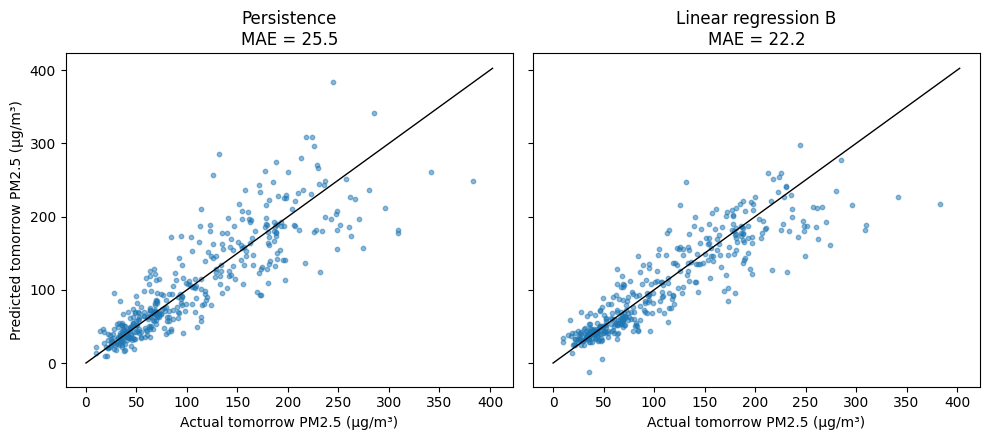

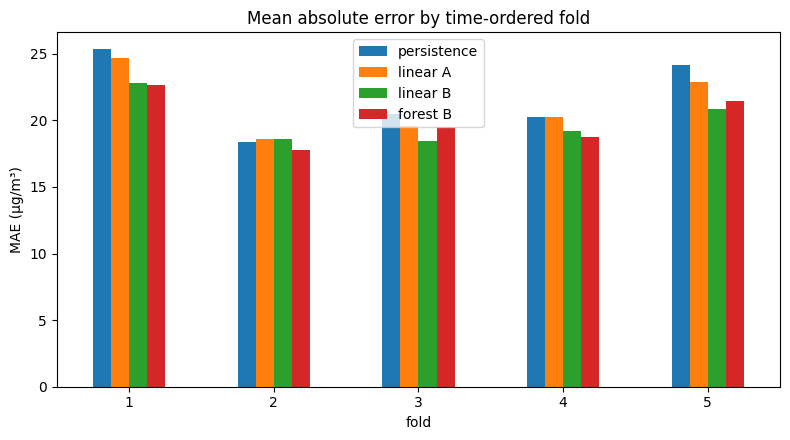

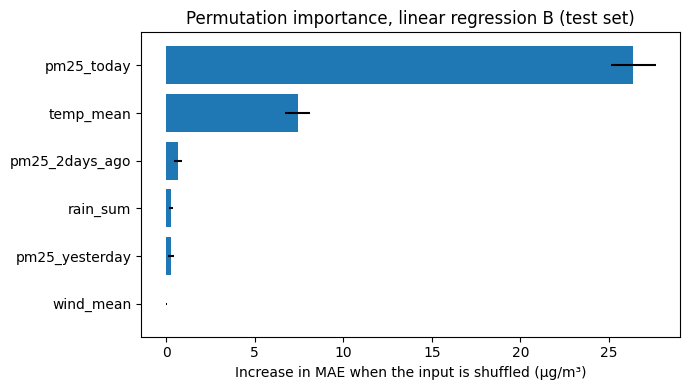

In [29]:
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)
lin_b = fitted[("linear", "B: PM2.5 + weather")]
pred_lin = lin_b.predict(test[all_features])
y_true = test["target_tomorrow"]

# Figure 1: actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
for ax, (name, pred) in zip(axes, [("Persistence", test["pm25_today"]), ("Linear regression B", pred_lin)]):
    ax.scatter(y_true, pred, s=10, alpha=0.5)
    lim = max(y_true.max(), np.max(pred)) * 1.05
    ax.plot([0, lim], [0, lim], color="black", linewidth=1)
    ax.set_title(f"{name}\nMAE = {mean_absolute_error(y_true, pred):.1f}")
    ax.set_xlabel("Actual tomorrow PM2.5 (µg/m³)")
axes[0].set_ylabel("Predicted tomorrow PM2.5 (µg/m³)")
plt.tight_layout()
plt.savefig("figures/actual_vs_predicted.png", dpi=150)
plt.show()

# Figure 2: MAE by fold
ax = cv.set_index("fold")[["persistence", "linear A", "linear B", "forest B"]].plot(
    kind="bar", figsize=(8, 4.5), rot=0
)
ax.set_ylabel("MAE (µg/m³)")
ax.set_title("Mean absolute error by time-ordered fold")
plt.tight_layout()
plt.savefig("figures/cv_mae_by_fold.png", dpi=150)
plt.show()

# Figure 3: permutation importance (linear B, test set)
r = permutation_importance(
    lin_b, test[all_features], y_true,
    scoring="neg_mean_absolute_error", n_repeats=20, random_state=42,
)
imp_b = pd.DataFrame({
    "feature": all_features,
    "MAE increase": r.importances_mean,
    "std": r.importances_std,
}).sort_values("MAE increase")
plt.figure(figsize=(7, 4))
plt.barh(imp_b["feature"], imp_b["MAE increase"], xerr=imp_b["std"])
plt.xlabel("Increase in MAE when the input is shuffled (µg/m³)")
plt.title("Permutation importance, linear regression B (test set)")
plt.tight_layout()
plt.savefig("figures/permutation_importance.png", dpi=150)
plt.show()

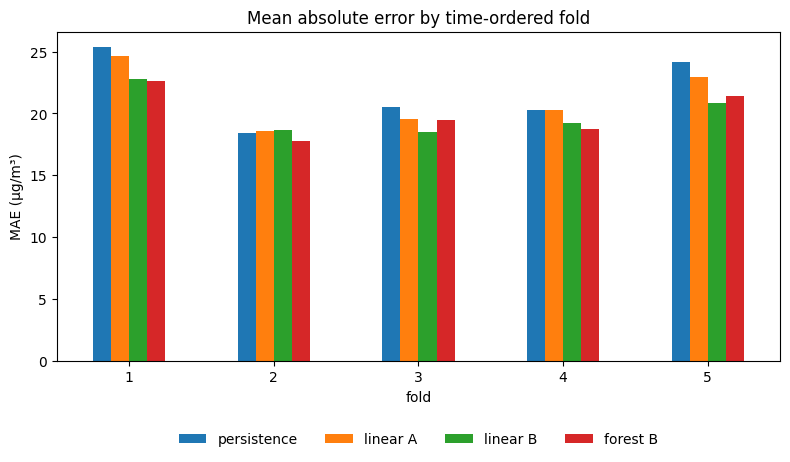

In [30]:
ax = cv.set_index("fold")[["persistence", "linear A", "linear B", "forest B"]].plot(
    kind="bar", figsize=(8, 4.8), rot=0
)
ax.set_ylabel("MAE (µg/m³)")
ax.set_title("Mean absolute error by time-ordered fold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False)
plt.tight_layout()
plt.savefig("figures/cv_mae_by_fold.png", dpi=150, bbox_inches="tight")
plt.show()